In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

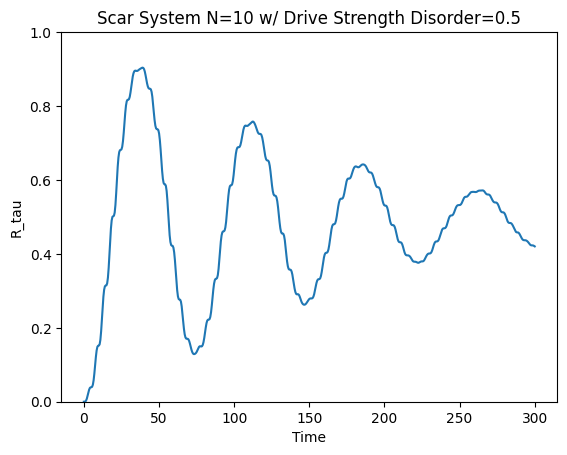

In [ ]:
N = 10
wd = 0.642570281124498
tlist = np.linspace(0, 300, 600)
d = 0.5
wm = 1.0

# scar system
H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, random_seed=True, ds_detuning=d, random_drive_strength=True)
args = {"A": 0.1, "omega": wd}
H = qt.QobjEvo([H0, [H1, coeff]], args=args)
psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])

# qH0, qH1 = get_qubit_ham(N, wm=wm, disorder=False, detuning=0.0, random_seed=True)
# qeigenvals, qeigenstates = qH0.eigenstates()
# qargs = {"A": 0.1, "omega": wm}
# H = qt.QobjEvo([H0, [H1, coeff]], args=qargs)
# qpsi_t = qt.sesolve(H, qeigenstates[0], tlist, e_ops=[qH0])


Rtau = np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])
plt.title(f"Scar System N={N} w/ Drive Strength Disorder={d}")
plt.ylabel("R_tau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.plot(tlist, Rtau)
plt.show()